In [2]:
#useful_libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, r2_score, precision_score, mean_squared_error
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor

In [3]:
#load_data
data = fetch_california_housing(as_frame = True)
df = pd.concat([data.data, data.target.rename("HousePrice")], axis = 1)

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
#split_data
x = df.drop("HousePrice", axis = 1)
y = df["HousePrice"]

In [5]:
#Feature Scaling
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)
x_scaled 

array([[ 2.34476576,  0.98214266,  0.62855945, ..., -0.04959654,
         1.05254828, -1.32783522],
       [ 2.33223796, -0.60701891,  0.32704136, ..., -0.09251223,
         1.04318455, -1.32284391],
       [ 1.7826994 ,  1.85618152,  1.15562047, ..., -0.02584253,
         1.03850269, -1.33282653],
       ...,
       [-1.14259331, -0.92485123, -0.09031802, ..., -0.0717345 ,
         1.77823747, -0.8237132 ],
       [-1.05458292, -0.84539315, -0.04021111, ..., -0.09122515,
         1.77823747, -0.87362627],
       [-0.78012947, -1.00430931, -0.07044252, ..., -0.04368215,
         1.75014627, -0.83369581]], shape=(20640, 8))

In [6]:
#train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [7]:
#ML models
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha = 1.0),
    "Decision Tree": DecisionTreeRegressor(max_depth = 5)
}    

In [8]:
#Model Evaluation and Comparision
results = {}

for name, model in models.items():
    model.fit(x_train, y_train)
    predictions = model.predict(x_test)

    rmse = mean_squared_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)
    

    results[name] = {
        "RMSE": rmse,
        "R2_score": r2
        
    }

results_df = pd.DataFrame(results).T
results_df

,RMSE,R2_score
Linear Regression,0.555892,0.575788
Ridge Regression,0.555803,0.575855
Decision Tree,0.524515,0.599732


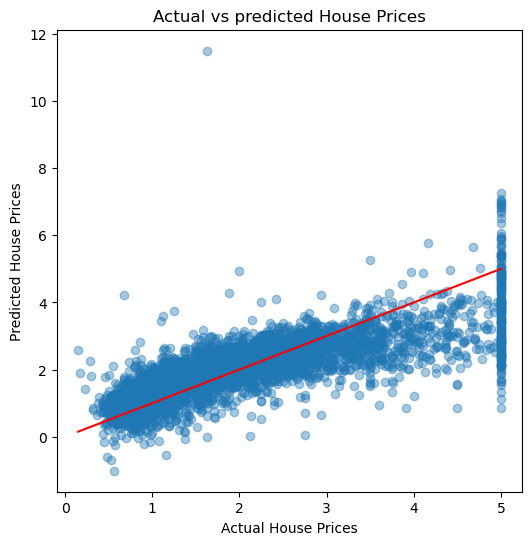

In [9]:
#visual performance
best_model = LinearRegression()
best_model.fit(x_train, y_train)

y_pred = best_model.predict(x_test)

plt.figure(figsize = (6,6))
plt.scatter(y_test, y_pred, alpha = 0.4)
plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Actual vs predicted House Prices")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color = "red")

plt.show()

In [10]:
results_df.to_csv("model_comparison.csv")
